In [1]:
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
import scipy.stats as sts
import astropy.units as u
import matplotlib.colors as mcol
import matplotlib.cm as mcm
from astropy.constants import G,M_sun,kpc
from matplotlib.lines import Line2D
from matplotlib.legend import Legend
'''
import matplotlib.colors as mcol
from matplotlib import ticker
from astropy.io import fits'''
import scipy.optimize as sopt
from sim_read import *

plt.rcParams["axes.linewidth"]  = 2
plt.rcParams["xtick.major.size"]  = 8
plt.rcParams["xtick.minor.size"]  = 3
plt.rcParams["ytick.major.size"]  = 8
plt.rcParams["ytick.minor.size"]  = 3
plt.rcParams["xtick.direction"]  = "in"
plt.rcParams["ytick.direction"]  = "in"
plt.rcParams["legend.frameon"] = 'False'
plt.rcParams.update({'font.size': 24})
plt.rcParams.update({'font.family': 'serif'})
plt.rcParams["mathtext.default"] = 'rm'
plt.rcParams["mathtext.fontset"] = 'cm'

In [2]:
gls = sim()
sim.mass_add(gls)

/Users/bhattacharyya.37/TNG50-1/sim_read.py:26: RuntimeWarning: divide by zero encountered in log10
  setattr(self.hst, 'group_m200', mconv + np.log10(self.hst.Group_M_Crit200))
/Users/bhattacharyya.37/TNG50-1/sim_read.py:27: RuntimeWarning: divide by zero encountered in log10
  setattr(self.hst,'group_mst', mconv + np.log10(self.hst.GroupMassType[:,4]))
/Users/bhattacharyya.37/TNG50-1/sim_read.py:28: RuntimeWarning: divide by zero encountered in log10
  setattr(self.sub,'mgas', mconv + np.log10(self.sub.SubhaloMassInRadType[:,0]))
/Users/bhattacharyya.37/TNG50-1/sim_read.py:29: RuntimeWarning: divide by zero encountered in log10
  setattr(self.sub,'mst',mconv + np.log10(self.sub.SubhaloMassInRadType[:,4]))


In [3]:
llt,llh,llg,llm,dhost = sim.field_select(gls)

N_lll = len(llh)
print(N_lll)

1464 10724
5089


In [4]:
host_bins = [np.where(llm==1)[0],np.where((llm>1))[0]]
bin_cols = ['royalblue','crimson']
bin_mk = ['o','D','s']
print(len(host_bins[0]),len(host_bins[1]))

sfms_intercept,sfms_slope = dwf_sfms(gls.sub.mst,gls.sub.ssfr)

4716 373
1464 10724
-8.335076377655438 -0.17656619725985392


/var/folders/h6/wvvht_j93kdd56hj5zln7l_h0vlgf3/T/ipykernel_51884/3108383800.py:8: RuntimeWarning: invalid value encountered in divide
  v = rv/r


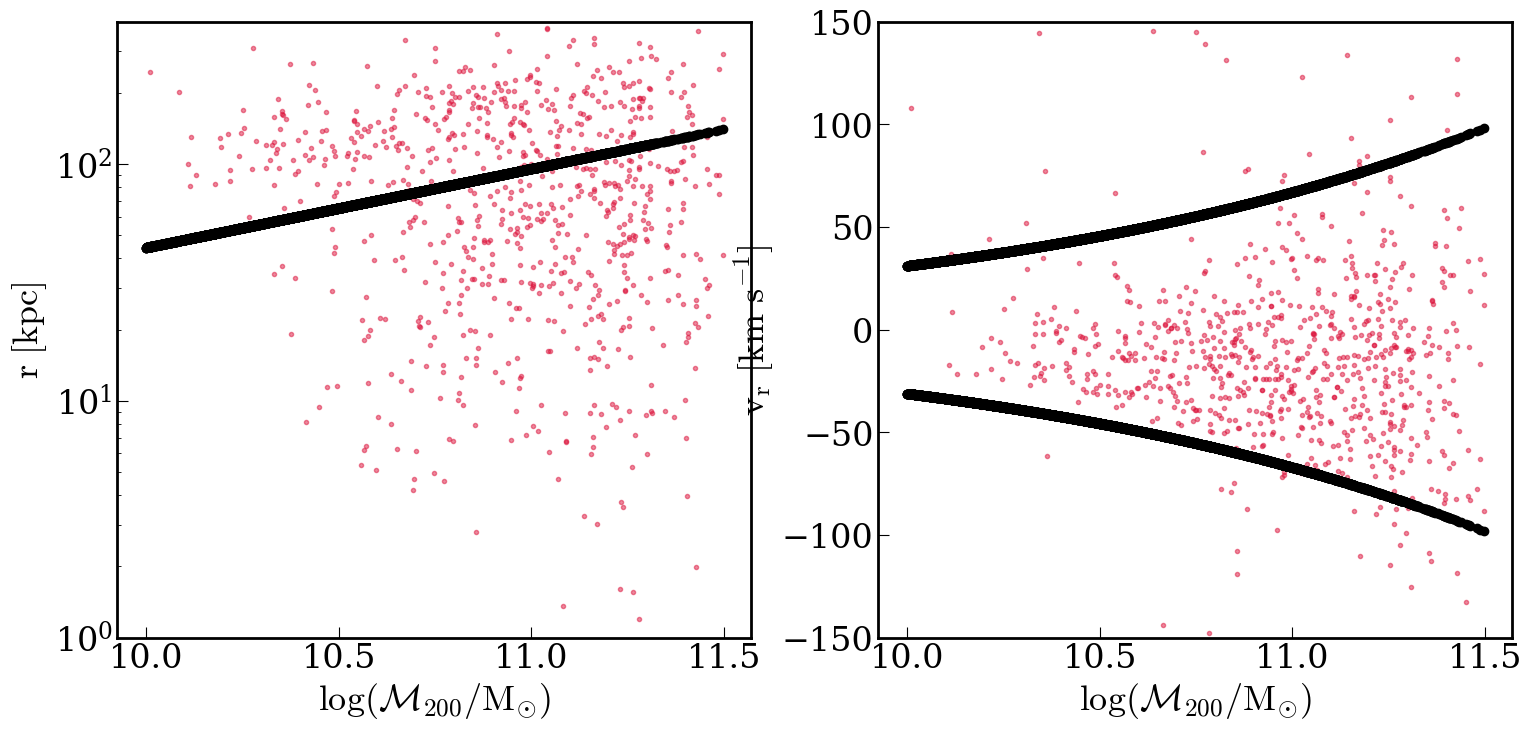

In [5]:
fig,ax=plt.subplots(1,2,figsize=(18,8),sharex=True)

for i in host_bins[1]:
            r = np.sqrt(np.square(gls.sub.SubhaloPos[cen,0]-gls.hst.GroupPos[llh[i],0])+np.square(gls.sub.SubhaloPos[cen,1]-gls.hst.GroupPos[llh[i],1])+np.square(gls.sub.SubhaloPos[cen,2]-gls.hst.GroupPos[llh[i],2]))
     
            #v = np.sqrt(np.square(gls.sub.SubhaloVel[cen,0]-gls.sub.SubhaloVel[lll[i],0])+np.square(gls.sub.SubhaloVel[cen,1]-gls.sub.SubhaloVel[lll[i],1])+np.square(gls.sub.SubhaloVel[cen,2]-gls.sub.SubhaloVel[lll[i],2]))
            rv = np.sum((gls.sub.SubhaloVel[cen,:]-gls.hst.GroupVel[llh[i],:])*(gls.sub.SubhaloPos[cen,:]-gls.hst.GroupPos[llh[i],:]),axis=1)
            v = rv/r
            #grp_vel.extend(4.8219e-3*v/np.sqrt(2*gls.hst.Group_M_Crit200[llh[i]]/gls.hst.Group_R_Crit200[llh[i]]))
    
            ax[0].plot(gls.hst.group_m200[llh[i]]*np.ones(llm[i]),r/0.7,'.',color=bin_cols[1],alpha=0.5)
            ax[1].plot(gls.hst.group_m200[llh[i]]*np.ones(llm[i]),v,'.',color=bin_cols[1],alpha=0.5)
            

        
ax[0].set_xlabel(r'$log(\mathcal{M}_{200}/M_{\odot})$',fontsize=26)
ax[1].set_xlabel(r'$log(\mathcal{M}_{200}/M_{\odot})$',fontsize=26)

v200 = np.sqrt(gls.hst.Group_M_Crit200[llh]/gls.hst.Group_R_Crit200[llh])/4.8219e-3

ax[0].plot(gls.hst.group_m200[llh],gls.hst.Group_R_Crit200[llh]/0.7,ls='none',color='black',marker='o')
ax[1].plot(gls.hst.group_m200[llh],v200,ls='none',color='black',marker='o')
ax[1].plot(gls.hst.group_m200[llh],-v200,ls='none',color='black',marker='o')

ax[0].set_ylabel(r'$r\ [kpc]$',fontsize=26)
ax[1].set_ylabel(r'$v_r\ [km\ s^{-1}]$',fontsize=26)

'''custom_lines = [Line2D([0], [0],lw=3, color=bin_cols[0]), Line2D([0], [0],lw=3, color=bin_cols[1])]
leg=Legend(ax[0],custom_lines,[r'$\mathcal{M}_{200}< 10^{11} M_\odot$',r'$10^{11} M_\odot < \mathcal{M}_{200}< 10^{12} M_\odot$'],loc='best',fontsize=20,framealpha=0.8,frameon=True)
ax[0].add_artist(leg)
'''
ax[0].set_ylim((1,400))
ax[1].set_ylim((-150,150))
ax[0].set_yscale('log')
#ax[0].set_ylim(bottom=1e-2)


Text(0, 0.5, '$v/V_{200}$')

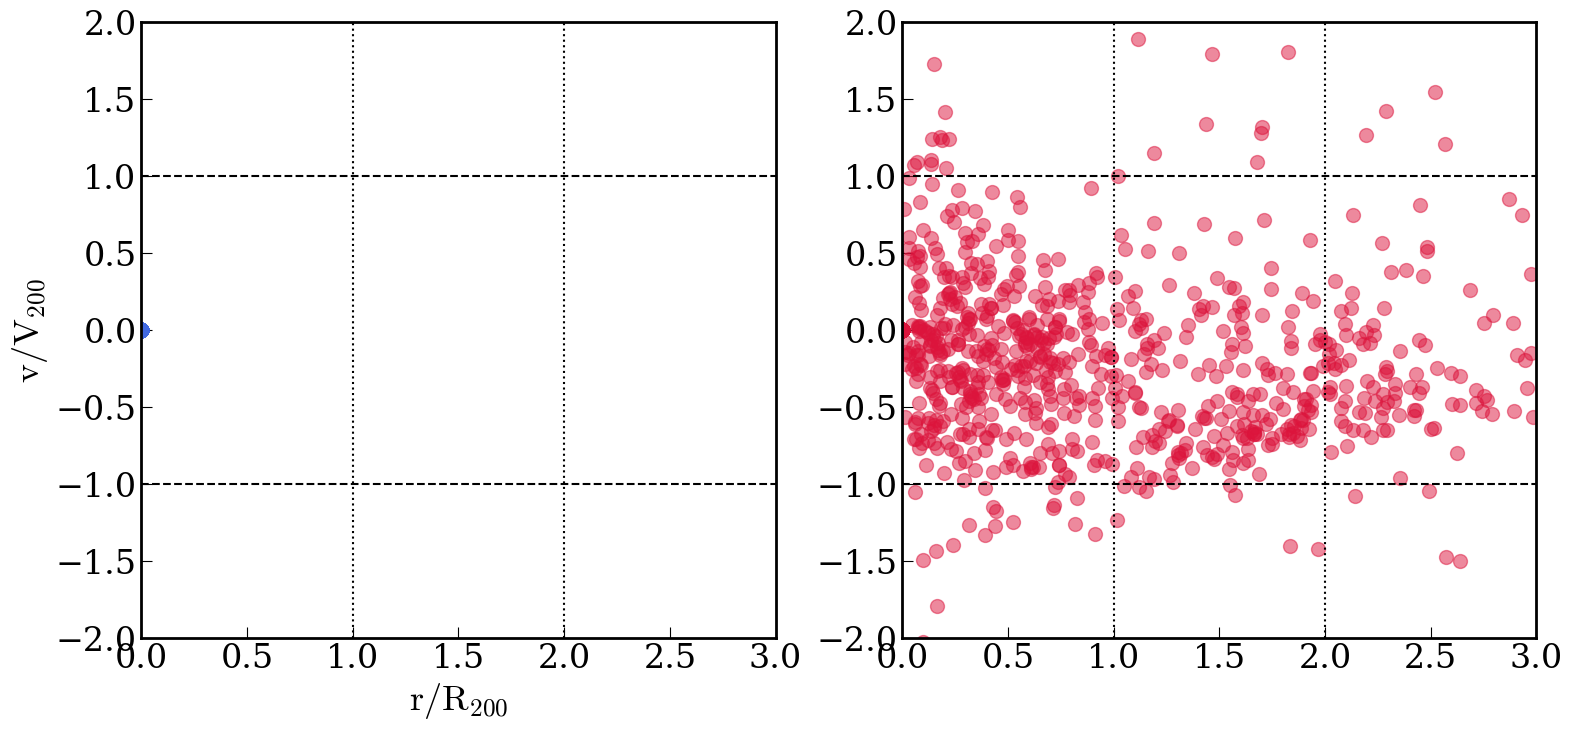

In [6]:
fig,ax=plt.subplots(1,2,figsize=(18,8),sharex=True)

for k in range(2):
    grp_rad,grp_vel = [],[]
    for i in host_bins[k]: 
        r = np.sqrt(np.square(gls.sub.SubhaloPos[cen,0]-gls.hst.GroupPos[llh[i],0])+np.square(gls.sub.SubhaloPos[cen,1]-gls.hst.GroupPos[llh[i],1])+np.square(gls.sub.SubhaloPos[cen,2]-gls.hst.GroupPos[llh[i],2]))
        rzr = np.where(r==0)[0]
        r[rzr] = 1e-10
        grp_rad.extend(r/gls.hst.Group_R_Crit200[llh[i]])
        
        rv = np.sum((gls.sub.SubhaloVel[cen,:]-gls.hst.GroupVel[llh[i],:])*(gls.sub.SubhaloPos[cen,:]-gls.hst.GroupPos[llh[i],:]),axis=1)
        v = rv/r
        grp_vel.extend(4.8219e-3*v/np.sqrt(gls.hst.Group_M_Crit200[llh[i]]/gls.hst.Group_R_Crit200[llh[i]]))
 
    ax[k].plot(grp_rad,grp_vel,'o',markersize=10,color=bin_cols[k],alpha=0.5)
    ax[k].set_xlim((0,3))
    ax[k].set_ylim((-2,2))
    ax[k].axhline(-1,color='black',ls='--')
    ax[k].axhline(1,color='black',ls='--')
    ax[k].axvline(1,color='black',ls=':')
    ax[k].axvline(2,color='black',ls=':')
    


ax[0].set_xlabel(r'$r/R_{200}$',fontsize=26)
ax[0].set_ylabel(r'$v/V_{200}$',fontsize=26)


/var/folders/h6/wvvht_j93kdd56hj5zln7l_h0vlgf3/T/ipykernel_43873/1300548639.py:11: RuntimeWarning: invalid value encountered in divide
  v = rv/r


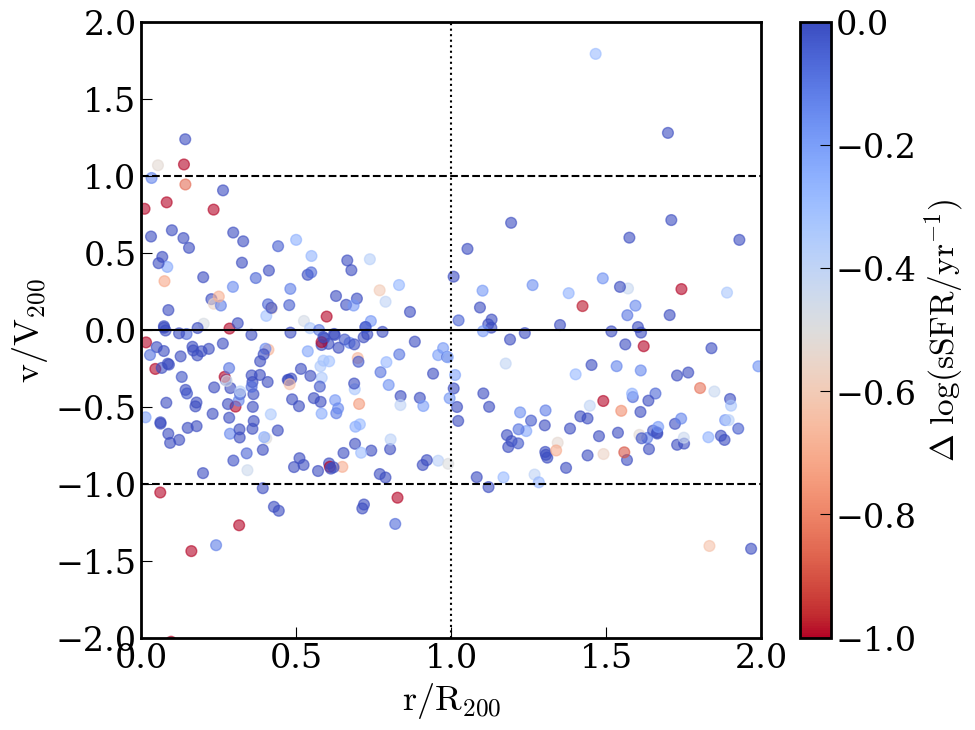

In [7]:
fig,ax=plt.subplots(figsize=(10,8))


grp_rad,grp_vel = [],[]
grp_col,grp_mrm = [],[]
for i in host_bins[1]: 
    r = np.sqrt(np.square(gls.sub.SubhaloPos[llg[i],0]-gls.hst.GroupPos[llh[i],0])+np.square(gls.sub.SubhaloPos[llg[i],1]-gls.hst.GroupPos[llh[i],1])+np.square(gls.sub.SubhaloPos[llg[i],2]-gls.hst.GroupPos[llh[i],2]))
    grp_rad.extend(r/gls.hst.Group_R_Crit200[llh[i]])
    
    rv = np.sum((gls.sub.SubhaloVel[llg[i],:]-gls.hst.GroupVel[llh[i],:])*(gls.sub.SubhaloPos[llg[i],:]-gls.hst.GroupPos[llh[i],:]),axis=1)
    v = rv/r
    grp_vel.extend(4.8219e-3*v/np.sqrt(gls.hst.Group_M_Crit200[llh[i]]/gls.hst.Group_R_Crit200[llh[i]]))
    
    grp_col.extend(gls.sub.ssfr[llg[i]]-(sfms_intercept + sfms_slope*gls.sub.mst[llg[i]]))

ax.scatter(grp_rad,grp_vel,c=grp_col,s=60,cmap=mcm.coolwarm_r,vmin=-1,vmax=0,alpha=0.6)

fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=-1, vmax=0),cmap=mcm.coolwarm_r), ax=ax, orientation='vertical',label=r'$\Delta\ log(sSFR/yr^{-1})$')


ax.set_xlim((0,2))
ax.set_ylim((-2,2))
ax.axhline(-1,color='black',ls='--')
ax.axhline(0,color='black')
ax.axhline(1,color='black',ls='--')
ax.axvline(1,color='black',ls=':')

ax.set_xlabel(r'$r/R_{200}$',fontsize=26)
ax.set_ylabel(r'$v/V_{200}$',fontsize=26)
plt.savefig('group_phasep.pdf',bbox_inches='tight')
